# Web Scraper

In [210]:
from bs4 import BeautifulSoup
import requests

Require input is the URL.

In [211]:
url = 'https://www.britannica.com/topic/list-of-state-capitals-in-the-United-States-2119210'
page = requests.get(url)
soup = BeautifulSoup(page.text, 'html')
# print(soup)

Find all tables in the page. In this website, though, there's only one so it's simple.

In [212]:
soup.find_all('table')

[<table data-sortable-table="true"> <thead> <tr> <th data-col-type="text" data-sortable-type="alpha">state</th> <th data-col-type="text" data-sortable-type="alpha">capital</th> <th data-col-type="number" data-sortable-type="numeric">population of capital: census</th> <th data-col-type="number" data-sortable-type="numeric">population of capital: estimated</th> </tr> </thead> <tbody> <tr> <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Alabama-state">Alabama</a></td> <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Montgomery-Alabama">Montgomery</a></td> <td>(2020) 200,603</td> <td>(2021 est.) 198,665</td> </tr> <tr> <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Alaska">Alaska</a></td> <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Juneau">Juneau</a></td> <td>(2020) 32,255</td>

Let's first get just the title of the table.

*Note: `<th>` tag defines a header cell in an HTML table*

In [213]:
titles = soup.find_all('th')
titles

[<th data-col-type="text" data-sortable-type="alpha">state</th>,
 <th data-col-type="text" data-sortable-type="alpha">capital</th>,
 <th data-col-type="number" data-sortable-type="numeric">population of capital: census</th>,
 <th data-col-type="number" data-sortable-type="numeric">population of capital: estimated</th>]

Since we do not need the tags, let's clean up the data.

In [214]:
titles_list = [title.text for title in titles]
titles_list

['state',
 'capital',
 'population of capital: census',
 'population of capital: estimated']

If the output still contains newline and other symbols that are not needed, you can further clean the data using, for example, ```.strip()```

Next, create a dataframe

In [215]:
import pandas as pd

df = pd.DataFrame(columns = titles_list)
df

,state,capital,population of capital: census,population of capital: estimated


Let's scrape the remaining data and fill this table!

In [216]:
rows = soup.find_all('tr')
len(rows)

51

The data of our interest are within the scope of **td** tags.

*Note: `<td>` tag defines a standard data cell in an HTML table.*

In [217]:
# -- Long version --
# row_data = []
# for row in rows:
#   row_data.append(row.find_all('td'))

# -- Short version --
row_data = [row.find_all('td') for row in rows]
row_data[1:5]

[[<td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Alabama-state">Alabama</a></td>,
  <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Montgomery-Alabama">Montgomery</a></td>,
  <td>(2020) 200,603</td>,
  <td>(2021 est.) 198,665</td>],
 [<td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Alaska">Alaska</a></td>,
  <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Juneau">Juneau</a></td>,
  <td>(2020) 32,255</td>,
  <td>(2021 est.) 31,973</td>],
 [<td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Arizona-state">Arizona</a></td>,
  <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Phoenix-Arizona">Phoenix</a></td>,
  <td>(2020) 1,608,139</td>,
  <td>(2021 est.) 1,624,569</td>],
 [<td><a

The first row collected has no value, thus an empty list.

In [218]:
row_data[0]

[]

Turns out the first row is actually here

In [219]:
row_data[1]

[<td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Alabama-state">Alabama</a></td>,
 <td><a class="md-crosslink sortable" data-show-preview="true" href="https://www.britannica.com/place/Montgomery-Alabama">Montgomery</a></td>,
 <td>(2020) 200,603</td>,
 <td>(2021 est.) 198,665</td>]

However, we only want the text portion.

In [220]:
print(row_data[1][0].text)
print(row_data[1][1].text)
print(row_data[1][2].text)
print(row_data[1][3].text)

Alabama
Montgomery
(2020) 200,603
(2021 est.) 198,665


Therefore, more cleaning is necessary.

Add the remaining rows to the dataframe.

But does this code work?

In [221]:
df.head()

,state,capital,population of capital: census,population of capital: estimated


In [232]:
rows = []
for i, each_row_data in enumerate(row_data):
    state = []
    
    for each_row_data_elem in each_row_data:
        state.append(each_row_data_elem.text)

    length = len(df)
    # print(state)
    if len(state) == 0:
        continue
    rows.append(state)

print(rows)
df = pd.DataFrame(rows, columns = titles_list)
    


[['Alabama', 'Montgomery', '(2020) 200,603', '(2021 est.) 198,665'], ['Alaska', 'Juneau', '(2020) 32,255', '(2021 est.) 31,973'], ['Arizona', 'Phoenix', '(2020) 1,608,139', '(2021 est.) 1,624,569'], ['Arkansas', 'Little Rock', '(2020) 202,591', '(2021 est.) 201,998'], ['California', 'Sacramento', '(2020) 524,943', '(2021 est.) 525,041'], ['Colorado', 'Denver', '(2020) 715,522', '(2021 est.) 711,463'], ['Connecticut', 'Hartford', '(2020) 121,054', '(2021 est.) 120,576'], ['Delaware', 'Dover', '(2020) 39,403', '(2021 est.) 38,992'], ['Florida', 'Tallahassee', '(2020) 196,068', '(2021 est.) 197,102'], ['Georgia', 'Atlanta', '(2020) 498,715', '(2021 est.) 496,461'], ['Hawaii', 'Honolulu', '(2020) 350,964', '(2021 est.) 345,510'], ['Idaho', 'Boise', '(2020) 235,684', '(2021 est.) 237,446'], ['Illinois', 'Springfield', '(2020) 114,394', '(2021 est.) 113,394'], ['Indiana', 'Indianapolis', '(2020) 887,642', '(2021 est.) 882,039'], ['Iowa', 'Des Moines', '(2020) 214,133', '(2021 est.) 212,031']

In [233]:
df

,state,capital,population of capital: census,population of capital: estimated
0,Alabama,Montgomery,"(2020) 200,603","(2021 est.) 198,665"
1,Alaska,Juneau,"(2020) 32,255","(2021 est.) 31,973"
2,Arizona,Phoenix,"(2020) 1,608,139","(2021 est.) 1,624,569"
3,Arkansas,Little Rock,"(2020) 202,591","(2021 est.) 201,998"
4,California,Sacramento,"(2020) 524,943","(2021 est.) 525,041"
5,Colorado,Denver,"(2020) 715,522","(2021 est.) 711,463"
6,Connecticut,Hartford,"(2020) 121,054","(2021 est.) 120,576"
7,Delaware,Dover,"(2020) 39,403","(2021 est.) 38,992"
8,Florida,Tallahassee,"(2020) 196,068","(2021 est.) 197,102"
9,Georgia,Atlanta,"(2020) 498,715","(2021 est.) 496,461"


TODO:

- Scrape other table from wikipedia
- Generate a new table/tables using dataframe
- Feel free to use other html tags
- Clean & preprocess

---

Other websites (for instance)
- https://www.timesjobs.com/
- https://www.tripadvisor.com/

# Activity 2: Moon Landing Conspiracy Theory

## Import Data

In [234]:
import requests
from bs4 import BeautifulSoup

url = 'https://en.wikipedia.org/wiki/Moon_landing_conspiracy_theories'
headers = {'User-Agent': 'CoolBot/0.0 (https://example.org/coolbot/; coolbot@example.org)'}

response = requests.get(url, headers=headers)

In [235]:
soup = BeautifulSoup(response.text, 'html')

In [236]:
paragraphs = soup.find_all('p')

In [237]:
paragraphs_text = [p.text for p in paragraphs]

In [238]:
paragraphs_text[4]

"An early and influential book about the subject of a Moon-landing conspiracy, We Never Went to the Moon: America's Thirty Billion Dollar Swindle, was self-published in 1976 by Bill Kaysing, a former US Navy officer with a Bachelor of Arts in English.[9] Despite having no knowledge of rockets or technical writing,[10] Kaysing was hired as a senior technical writer in 1956 by Rocketdyne, the company that built the F-1 engines used on the Saturn V rocket.[11][12] He served as head of the technical publications unit at the company's Propulsion Field Laboratory until 1963. The many allegations in Kaysing's book effectively began discussion of the Moon landings being faked.[13][14] The book claims that the chance of a successful crewed landing on the Moon was calculated to be 0.0017%, and that despite close monitoring by the USSR, it would have been easier for NASA to fake the Moon landings than to really go there.[15][16]\n"

## Analysis of media (books, films, documetaries) (in *italic form*)

In [239]:
paragraphs[3].find_all('i')

[<i>Conspiracy Theory: Did We Land on the Moon?</i>]

In [240]:
len(paragraphs)

103

In [241]:
paragraph_start = 3
paragraph_end = 98

In [242]:
paragraphs[31]

<p>1. The astronauts could not have survived the trip because of exposure to radiation from the <a href="/wiki/Van_Allen_radiation_belt" title="Van Allen radiation belt">Van Allen radiation belt</a> and galactic ambient radiation (see <a href="/wiki/Acute_radiation_syndrome" title="Acute radiation syndrome">radiation poisoning</a> and <a class="mw-redirect" href="/wiki/Health_threat_from_cosmic_rays" title="Health threat from cosmic rays">health threat from cosmic rays</a>). Some conspiracists have suggested that <a href="/wiki/Starfish_Prime" title="Starfish Prime">Starfish Prime</a> (a <a href="/wiki/High-altitude_nuclear_explosion" title="High-altitude nuclear explosion">high-altitude nuclear test</a> in 1962) formed another intense layer on the Van Allen belt.<sup class="reference" id="cite_ref-envrad_89-0"><a href="#cite_note-envrad-89"><span class="cite-bracket">[</span>86<span class="cite-bracket">]</span></a></sup>
</p>

In [243]:
print(paragraphs[5])
paragraphs[5].find_all('i')

<p>In 1980, the <a class="mw-redirect" href="/wiki/International_Flat_Earth_Research_Society" title="International Flat Earth Research Society">Flat Earth Society</a> accused NASA of faking the landings, arguing that they were staged by Hollywood with <a href="/wiki/Walt_Disney" title="Walt Disney">Walt Disney</a> sponsorship, based on a script by <a href="/wiki/Arthur_C._Clarke" title="Arthur C. Clarke">Arthur C. Clarke</a> and directed by <a href="/wiki/Stanley_Kubrick" title="Stanley Kubrick">Stanley Kubrick</a>.<sup class="reference" id="cite_ref-17"><a href="#cite_note-17"><span class="cite-bracket">[</span>a<span class="cite-bracket">]</span></a></sup><sup class="reference" id="cite_ref-18"><a href="#cite_note-18"><span class="cite-bracket">[</span>17<span class="cite-bracket">]</span></a></sup> Folklorist <a href="/wiki/Linda_D%C3%A9gh" title="Linda Dégh">Linda Dégh</a> suggests that writer-director <a href="/wiki/Peter_Hyams" title="Peter Hyams">Peter Hyams</a>' film <i><a href

[<i><a href="/wiki/Capricorn_One" title="Capricorn One">Capricorn One</a></i>,
 <i><a href="/wiki/A_Man_on_the_Moon" title="A Man on the Moon">A Man on the Moon</a></i>]

In [244]:
media = [paragraphs[i].find_all('i') for i in range(paragraph_start,paragraph_end+1)]

In [245]:
# media[2][0].text
media_string = []
for i in range(len(media)):
    for j in range(len(media[i])):
        media_string.append(media[i][j].text)
        print(media[i][j].text)

Conspiracy Theory: Did We Land on the Moon?
We Never Went to the Moon: America's Thirty Billion Dollar Swindle
Capricorn One
A Man on the Moon
Bad Astronomy
Great Soviet Encyclopedia
Dark Moon: Apollo and the Whistle-Blowers
did
Penn & Teller: Bullshit!
The West Australian
Moon Shot
e.g.
before
We Never Went to the Moon
Conspiracy Theory: Did We Land on the Moon?
2001: A Space Odyssey
2001
2001
2001
2001
2001
Barry Lyndon
Dark Side of the Moon
Opération Lune
Opération Lune
Dr. Strangelove
The Shining
Moonwalkers
MythBusters
MythBusters
The Daily Telegraph
Intrepid
citation needed
Did We Go?
sic
The Washington Post
Time/CNN
Conspiracy Theory: Did We Land on the Moon?
ФОМ
Engineering & Technology
Back to Godhead


In [246]:
print(media_string)

['Conspiracy Theory: Did We Land on the Moon?', "We Never Went to the Moon: America's Thirty Billion Dollar Swindle", 'Capricorn One', 'A Man on the Moon', 'Bad Astronomy', 'Great Soviet Encyclopedia', 'Dark Moon: Apollo and the Whistle-Blowers', 'did', 'Penn & Teller: Bullshit!', 'The West Australian', 'Moon Shot', 'e.g.', 'before', 'We Never Went to the Moon', 'Conspiracy Theory: Did We Land on the Moon?', '2001: A Space Odyssey', '2001', '2001', '2001', '2001', '2001', 'Barry Lyndon', 'Dark Side of the Moon', 'Opération Lune', 'Opération Lune', 'Dr. Strangelove', 'The Shining', 'Moonwalkers', 'MythBusters', 'MythBusters', 'The Daily Telegraph', 'Intrepid', 'citation needed', 'Did We Go?', 'sic', 'The Washington Post', 'Time/CNN', 'Conspiracy Theory: Did We Land on the Moon?', 'ФОМ', 'Engineering & Technology', 'Back to Godhead']


> Note that some *italic* specify a **Preposition** (e.g, *before*). So I filter only the one which starts with **Capital alphabet** only

In [247]:
media_string_upper = [i for i in media_string if i and not i[0].islower()]

In [248]:
media_string_upper

['Conspiracy Theory: Did We Land on the Moon?',
 "We Never Went to the Moon: America's Thirty Billion Dollar Swindle",
 'Capricorn One',
 'A Man on the Moon',
 'Bad Astronomy',
 'Great Soviet Encyclopedia',
 'Dark Moon: Apollo and the Whistle-Blowers',
 'Penn & Teller: Bullshit!',
 'The West Australian',
 'Moon Shot',
 'We Never Went to the Moon',
 'Conspiracy Theory: Did We Land on the Moon?',
 '2001: A Space Odyssey',
 '2001',
 '2001',
 '2001',
 '2001',
 '2001',
 'Barry Lyndon',
 'Dark Side of the Moon',
 'Opération Lune',
 'Opération Lune',
 'Dr. Strangelove',
 'The Shining',
 'Moonwalkers',
 'MythBusters',
 'MythBusters',
 'The Daily Telegraph',
 'Intrepid',
 'Did We Go?',
 'The Washington Post',
 'Time/CNN',
 'Conspiracy Theory: Did We Land on the Moon?',
 'ФОМ',
 'Engineering & Technology',
 'Back to Godhead']

> We found that the *2001* refers to the same media (*2001: A Space Odyssey*) so we replace the string *2001* to *2001: A Space Odyssey*)

In [249]:
media_string_upper = ['2001: A Space Odyssey' if i == '2001' else i for i in media_string_upper]

In [250]:
media_string_upper

['Conspiracy Theory: Did We Land on the Moon?',
 "We Never Went to the Moon: America's Thirty Billion Dollar Swindle",
 'Capricorn One',
 'A Man on the Moon',
 'Bad Astronomy',
 'Great Soviet Encyclopedia',
 'Dark Moon: Apollo and the Whistle-Blowers',
 'Penn & Teller: Bullshit!',
 'The West Australian',
 'Moon Shot',
 'We Never Went to the Moon',
 'Conspiracy Theory: Did We Land on the Moon?',
 '2001: A Space Odyssey',
 '2001: A Space Odyssey',
 '2001: A Space Odyssey',
 '2001: A Space Odyssey',
 '2001: A Space Odyssey',
 '2001: A Space Odyssey',
 'Barry Lyndon',
 'Dark Side of the Moon',
 'Opération Lune',
 'Opération Lune',
 'Dr. Strangelove',
 'The Shining',
 'Moonwalkers',
 'MythBusters',
 'MythBusters',
 'The Daily Telegraph',
 'Intrepid',
 'Did We Go?',
 'The Washington Post',
 'Time/CNN',
 'Conspiracy Theory: Did We Land on the Moon?',
 'ФОМ',
 'Engineering & Technology',
 'Back to Godhead']

> We then visualize with ***Bar Graph***

In [251]:
from collections import Counter
import matplotlib.pyplot as plt

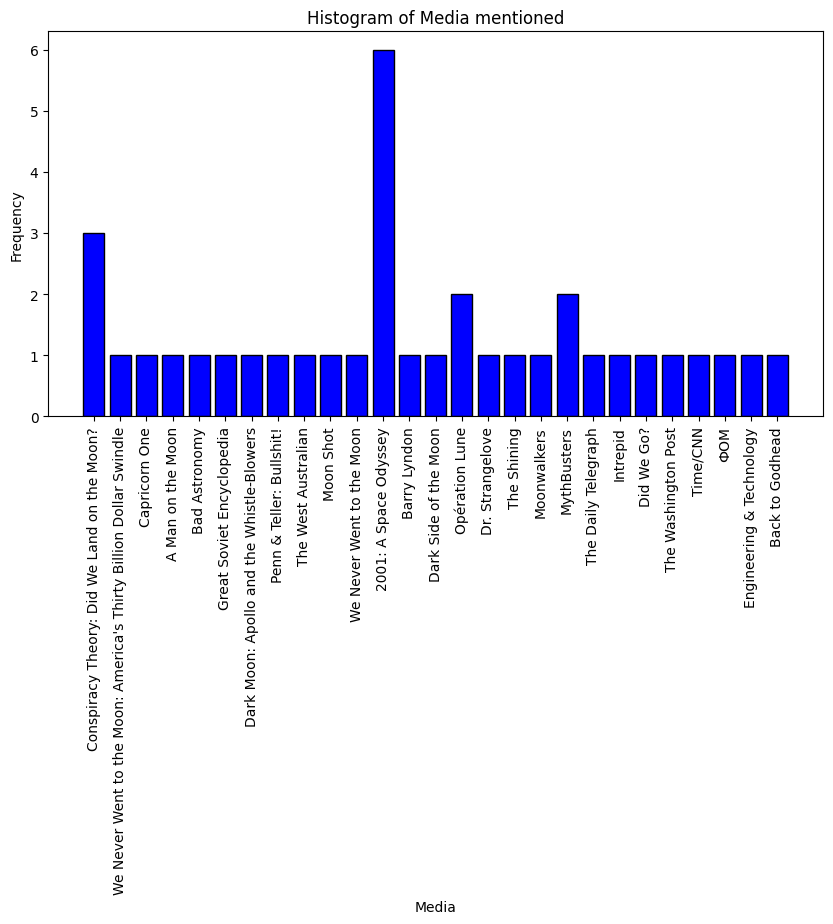

In [252]:
freq = Counter(media_string_upper)

label = freq.keys()
value = freq.values()

plt.figure(figsize=(10,5))
plt.bar(label, value, color='blue', edgecolor='black')
plt.title('Histogram of Media mentioned')
plt.xlabel('Media')
plt.xticks(rotation=90)
plt.ylabel('Frequency')
plt.show()

> We found out that the media **2001: A Space Odyssey** got the **MOST** number of mentions

## Find the **Frequently** mentioned **YEAR** in the entire article

In [253]:
from wordcloud import WordCloud
import re

In [254]:
paragraphs_text[1:paragraph_end+1];

In [255]:
year_pattern = r'[1-2]\d{3}'  
# year_pattern = r'\d{4}'

In [256]:
year_list = []
for paragraph in paragraphs_text[1:paragraph_end+1]:
    year_match = re.findall(year_pattern, paragraph)
    year_list.extend(year_match)

In [257]:
print(year_list)

['1969', '1972', '1970', '2000', '2012', '1994', '2009', '2001', '1969', '1976', '1956', '1963', '1980', '1978', '1994', '1968', '1962', '2002', '1970', '1979', '1957', '1961', '1972', '1970', '1972', '1959', '1962', '2023', '1961', '1973', '2001', '2009', '1966', '1972', '2005', '1994', '1962', '1977', '1970', '1984', '1967', '2006', '2009', '2009', '1957', '1957', '1961', '1963', '1965', '1965', '1961', '1970', '1980', '1969', '1972', '1970', '1971', '1973', '2019', '2024', '1969', '1972', '1968', '1972', '1961', '1972', '1966', '1977', '2001', '2001', '2001', '1968', '2001', '2001', '2001', '2001', '1975', '2002', '1995', '2009', '1980', '2015', '2015', '1999', '2002', '2002', '2004', '2004', '2008', '2001', '2002', '2002', '2007', '2008', '2009', '2009', '2009', '2008', '2010', '1967', '1979', '1982', '1969', '1972', '1969', '1971', '1971', '1994', '1999', '1995', '2001', '2000', '2009', '1977', '1970', '2019', '1969']


In [258]:
year_list = [int(y) for y in year_list]

In [259]:
year_list[0:9]

[1969, 1972, 1970, 2000, 2012, 1994, 2009, 2001, 1969]

Text(0.5, 1.0, 'Histogram of Years mentioned')

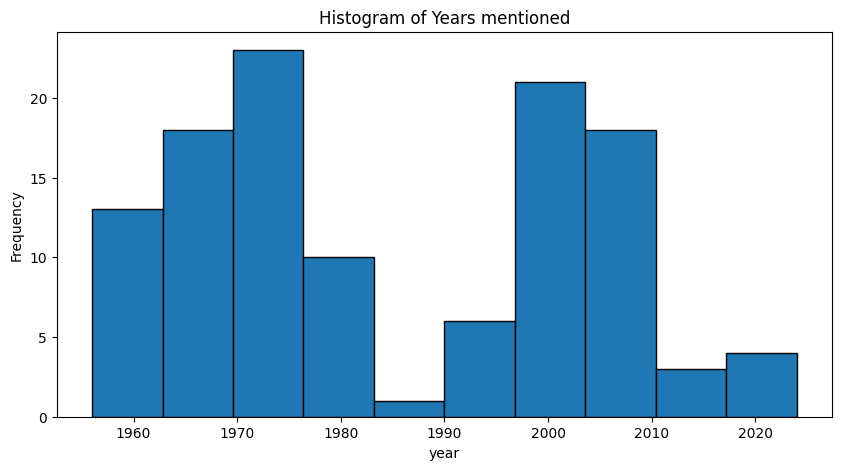

In [260]:
plt.figure(figsize=(10,5))
plt.hist(year_list, bins=10, edgecolor='black')
plt.xlabel('year')
plt.ylabel('Frequency')
plt.title('Histogram of Years mentioned')

> It seems that the article mentioned the decades 60' - 70' the most. The second one is 2000's

## Find the most mentioned organization / Institute / States using word cloud

In [261]:
organization_pattern = r'[A-Z]{3,100}'

In [262]:
organiztion_list = []
for paragraph in paragraphs_text[1:paragraph_end+1]:
    organization_match = re.findall(organization_pattern, paragraph)
    organiztion_list.extend(organization_match)

In [263]:
organiztion_list[0:20]

['NASA',
 'NASA',
 'LRO',
 'NASA',
 'USSR',
 'NASA',
 'NASA',
 'NASA',
 'NASA',
 'NASA',
 'NASA',
 'NASA',
 'NASA',
 'NASA',
 'NASA',
 'NASA',
 'NASA',
 'NASA',
 'NASA',
 'NASA']

In [264]:
organization_text = ' '.join(org for org in organiztion_list)

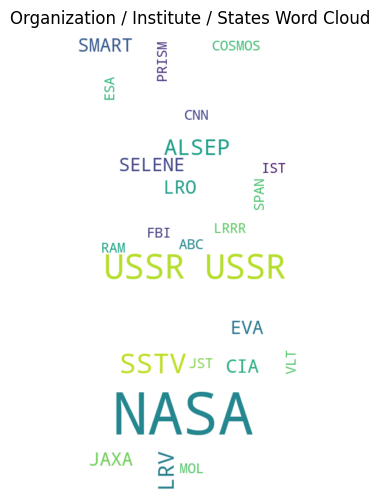

In [265]:
wordcloud = WordCloud(height=800, width=400, background_color='white').generate(organization_text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Organization / Institute / States Word Cloud')
plt.show()

> I found out that `NASA` holds the **MOST mentioned** in this article